<a href="https://colab.research.google.com/github/Polineska/Burnout-and-leave-ML-models/blob/main/Employee_leave.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install catboost

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report


In [ ]:
drive.mount("/content/drive")
df = pd.read_csv("/content/drive/MyDrive/4 курс/ВКР/Employee.csv")
print("Размер датасета:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Размер датасета: (4653, 9)


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [ ]:
df.describe(include='all')

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
count,4653,4653.000000,4653,4653.000000,4653.000000,4653,4653,4653.000000,4653.000000
unique,3,NaN,3,NaN,NaN,2,2,NaN,NaN
top,Bachelors,NaN,Bangalore,NaN,NaN,Male,No,NaN,NaN
freq,3601,NaN,2228,NaN,NaN,2778,4175,NaN,NaN
mean,NaN,2015.062970,NaN,2.698259,29.393295,NaN,NaN,2.905652,0.343864
std,NaN,1.863377,NaN,0.561435,4.826087,NaN,NaN,1.558240,0.475047
min,NaN,2012.000000,NaN,1.000000,22.000000,NaN,NaN,0.000000,0.000000
25%,NaN,2013.000000,NaN,3.000000,26.000000,NaN,NaN,2.000000,0.000000
50%,NaN,2015.000000,NaN,3.000000,28.000000,NaN,NaN,3.000000,0.000000
75%,NaN,2017.000000,NaN,3.000000,32.000000,NaN,NaN,4.000000,1.000000


In [ ]:
# Проверка пропусков
df.isna().sum()

,0
Education,0
JoiningYear,0
City,0
PaymentTier,0
Age,0
Gender,0
EverBenched,0
ExperienceInCurrentDomain,0
LeaveOrNot,0


In [ ]:
#прверка количества дубликатов
df.duplicated().sum()

np.int64(1889)

In [ ]:
#очистим датсет от дубликатов
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:
df=df.reset_index(drop=True)
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


Анализ датасета

In [ ]:
df['JoiningYear'].value_counts()

,count
JoiningYear,
2017,662
2015,464
2013,396
2014,385
2016,310
2012,308
2018,239


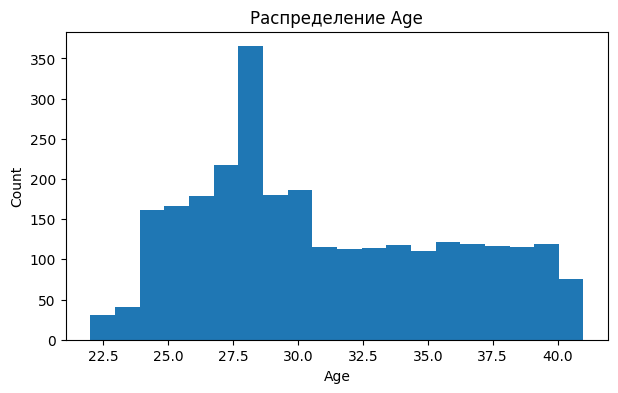

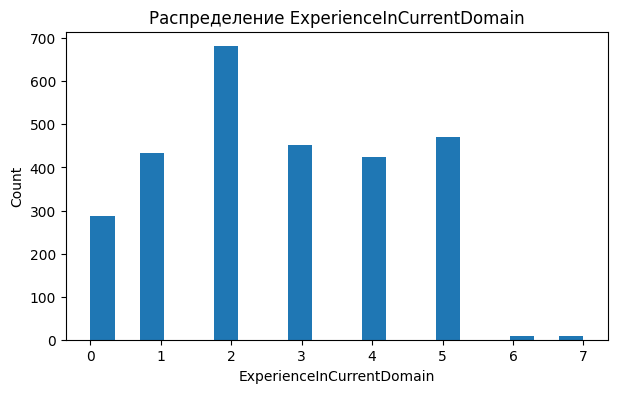

In [ ]:
num_cols = ["Age", "ExperienceInCurrentDomain"]

for col in num_cols:
    plt.figure(figsize=(7,4))
    plt.hist(df[col], bins=20)
    plt.title(f"Распределение {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [ ]:
df['Age'].describe()

,Age
count,2764.000000
mean,30.952967
std,5.108872
min,22.000000
25%,27.000000
50%,30.000000
75%,35.000000
max,41.000000


Большинство сотрудников находятся в возрастном диапазоне от 25 до 28 лет, что указывает на относительно молодую рабочую силу.Большинство сотрудников имеют опыт работы в своей текущей области до 5 лет, а максимальный стаж составляет около 2 лет.

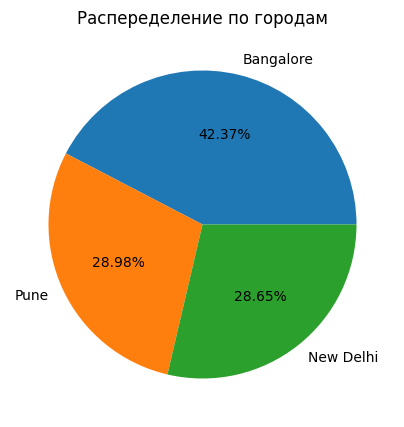

In [ ]:
plt.figure(figsize=(14,5))
plt.pie(x=df['City'].value_counts(),labels=df['City'].value_counts().index,autopct="%1.2f%%")
plt.title("Распеределение по городам")
plt.show()

Большинство сотрудников работают в Bangalore

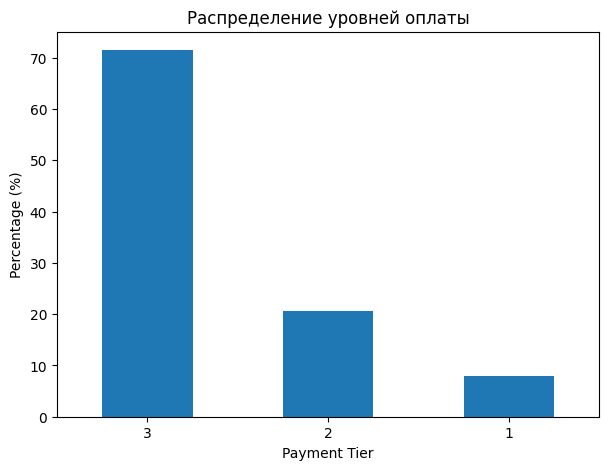

In [ ]:
payment_tier_distribution = df['PaymentTier'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
payment_tier_distribution.plot(kind='bar')
plt.title('Распределение уровней оплаты')
plt.xlabel('Payment Tier')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.show()

Большинство имеют высокий, 3 уровень оплаты

In [ ]:
df['LeaveOrNot'].value_counts()

,count
LeaveOrNot,
0,1676
1,1088


In [ ]:
num_employees_left = df['LeaveOrNot'].sum()
print(f"Количество уволенных сотрудников: {num_employees_left}")

Количество уволенных сотрудников: 1088


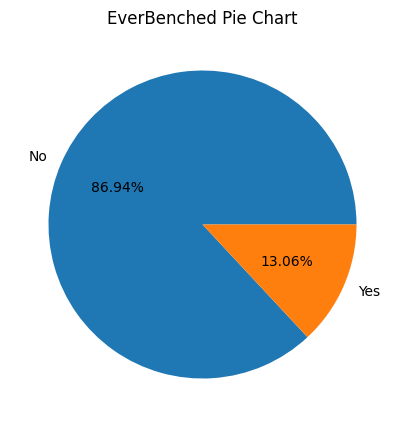

In [ ]:
plt.figure(figsize=(14,5))
plt.pie(x=df['EverBenched'].value_counts(),labels=df['EverBenched'].value_counts().index,autopct="%1.2f%%")
plt.title("EverBenched Pie Chart")
plt.show()

Большинство сотрудников никогда не были без работы

In [ ]:
#Зависимость уровня образования от увольнения
df.groupby('Education')['LeaveOrNot'].value_counts()

Education  LeaveOrNot
Bachelors  0             1232
           1              739
Masters    0              328
           1              309
PHD        0              116
           1               40
Name: count, dtype: int64

In [ ]:
#Зависимость года приянтия от увольнения
df.groupby('LeaveOrNot')['JoiningYear'].value_counts(normalize=True)*100

LeaveOrNot  JoiningYear
0           2017           27.505967
            2015           16.229117
            2014           15.871122
            2012           13.424821
            2013           13.424821
            2016           13.245823
            2018            0.298329
1           2018           21.507353
            2017           18.474265
            2015           17.647059
            2013           15.716912
            2014           10.937500
            2016            8.088235
            2012            7.628676
Name: proportion, dtype: float64

In [ ]:
df.groupby('LeaveOrNot')['City'].value_counts(normalize=True)*100

LeaveOrNot  City     
0           Bangalore    45.405728
            New Delhi    31.145585
            Pune         23.448687
1           Bangalore    37.683824
            Pune         37.500000
            New Delhi    24.816176
Name: proportion, dtype: float64

In [ ]:
df.groupby('LeaveOrNot')['PaymentTier'].value_counts(normalize=True)*100

LeaveOrNot  PaymentTier
0           3              78.042959
            2              13.544153
            1               8.412888
1           3              61.397059
            2              31.525735
            1               7.077206
Name: proportion, dtype: float64

In [ ]:
df.groupby('LeaveOrNot')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
LeaveOrNot,,,,,,,,
0,1676.0,31.426014,5.115258,22.0,28.0,30.0,36.0,41.0
1,1088.0,30.224265,5.014723,22.0,26.0,29.0,34.0,41.0


In [ ]:
df.groupby('LeaveOrNot')['Gender'].value_counts(normalize=True)*100

LeaveOrNot  Gender
0           Male      62.947494
            Female    37.052506
1           Female    56.433824
            Male      43.566176
Name: proportion, dtype: float64

In [ ]:
df.groupby('LeaveOrNot')['EverBenched'].value_counts(normalize=True)*100

LeaveOrNot  EverBenched
0           No             87.947494
            Yes            12.052506
1           No             85.386029
            Yes            14.613971
Name: proportion, dtype: float64

In [ ]:
df.groupby('LeaveOrNot')['ExperienceInCurrentDomain'].value_counts(normalize=True)*100

LeaveOrNot  ExperienceInCurrentDomain
0           2                            23.269690
            5                            18.496420
            1                            16.288783
            4                            15.393795
            3                            15.214797
            0                            10.620525
            6                             0.357995
            7                             0.357995
1           2                            26.746324
            3                            18.014706
            4                            15.349265
            1                            14.705882
            5                            14.705882
            0                            10.018382
            7                             0.275735
            6                             0.183824
Name: proportion, dtype: float64

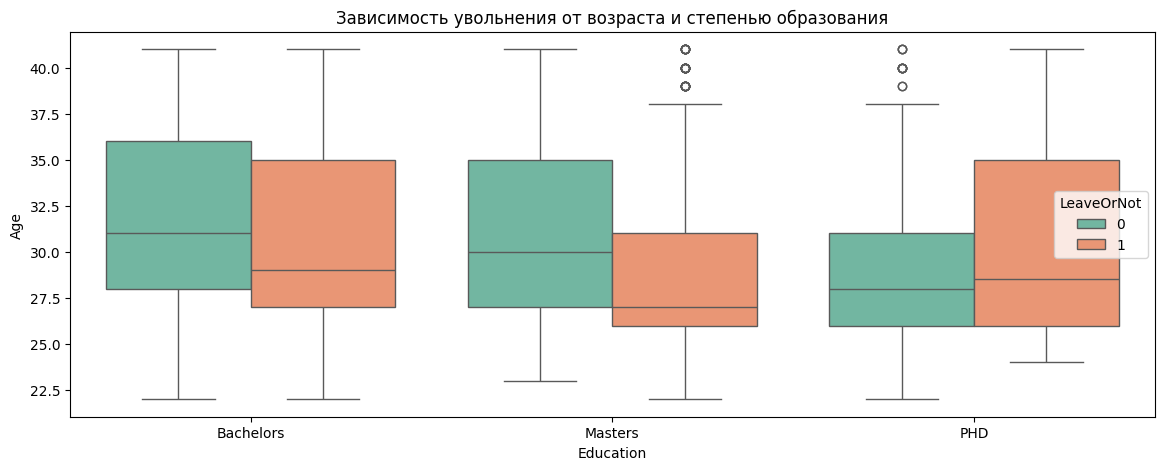

In [ ]:
plt.figure(figsize=(14,5))
sns.boxplot(data=df,x='Education',y='Age',hue='LeaveOrNot',palette='Set2')
plt.title("Зависимость увольнения от возраста и степенью образования")
plt.show()

Возраст является фактором удержания, чем старше сотрудник, тем ниже вероятность ухода, независимо от уровня образования. Наибольшая текучесть наблюдается среди молодых специалистов с Bachelor и Master.Для Bachelors наименьшая разница в возрасте между уходящими и остающимися

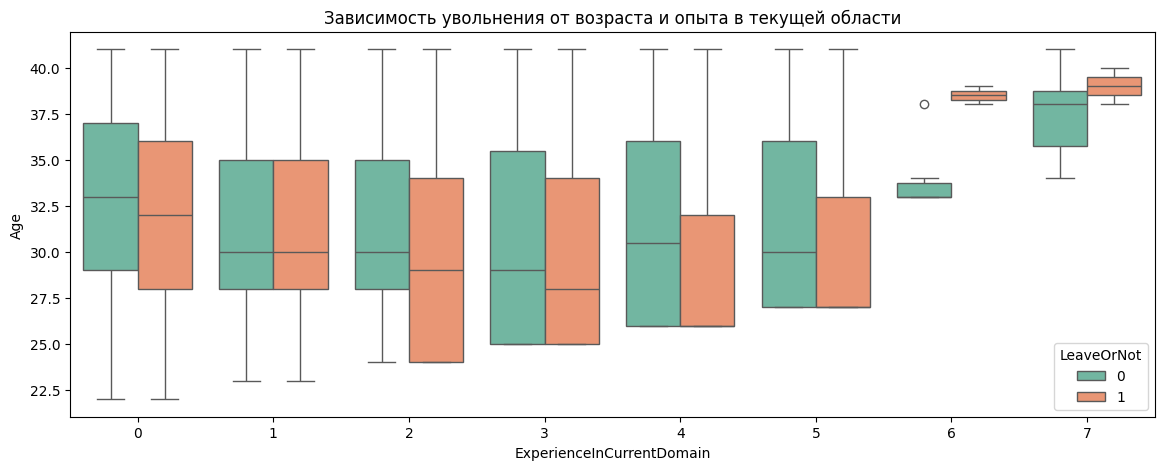

In [ ]:
plt.figure(figsize=(14,5))
sns.boxplot(data=df, x='ExperienceInCurrentDomain', y='Age', hue='LeaveOrNot', palette='Set2')
plt.title("Зависимость увольнения от возраста и опыта в текущей области")
plt.show()

У сотрудников **с малым опытом** (0-2 года) разница в возрасте между уволившимися и оставшимися незначительна.Для **среднего опыта** сотрудники, которые уходят, как правило моложе. Медианный возраст уволившихся ниже, чем у оставшихся. Разброс возрастов у уволившихся больше, длиннее усы.
Для **большого опыта** разница становится еще более выраженной.Чем больше опыт в текущей области, тем сильнее возраст влияет на решение об уходе. Возрастные сотрудники с большим опытом демонстрируют высокую лояльность


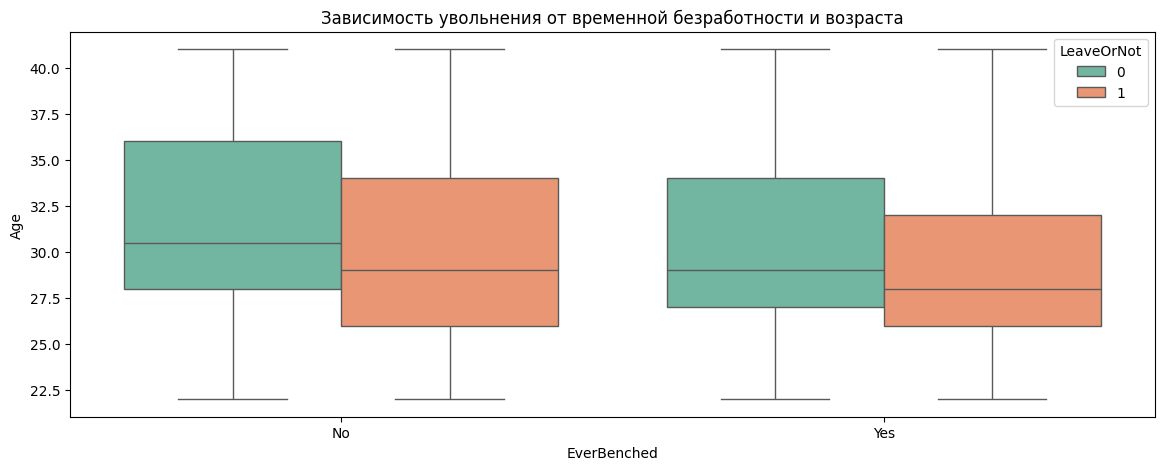

In [ ]:
plt.figure(figsize=(14,5))
sns.boxplot(data=df,x='EverBenched',y='Age',hue='LeaveOrNot',palette='Set2')
plt.title("Зависимость увольнения от временной безработности и возраста")
plt.show()

Сотрудники, которые были временно без работы, в среднем моложе и чаще уходят из компании. Среди сотрудников, которые были без работы, возраст уходящих и не уходящих ближе друг к другу, что может указывать на то, что сам факт, что чкловек когда-то был без работы повышает риск ухода независимо от возраста.


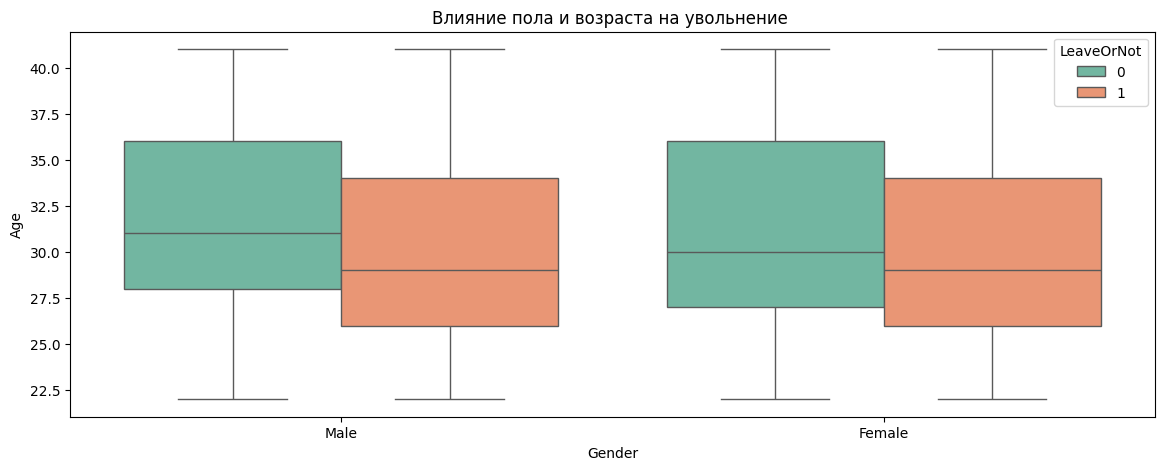

In [ ]:
plt.figure(figsize=(14,5))
sns.boxplot(data=df,x='Gender',y='Age',hue='LeaveOrNot',palette='Set2')
plt.title("Влияние пола и возраста на увольнение ")
plt.show()

Пол не оказывает особого влияния на вероятность увольнения, тогда как возраст является более значимым фактором риск ухода выше у более молодых сотрудников.

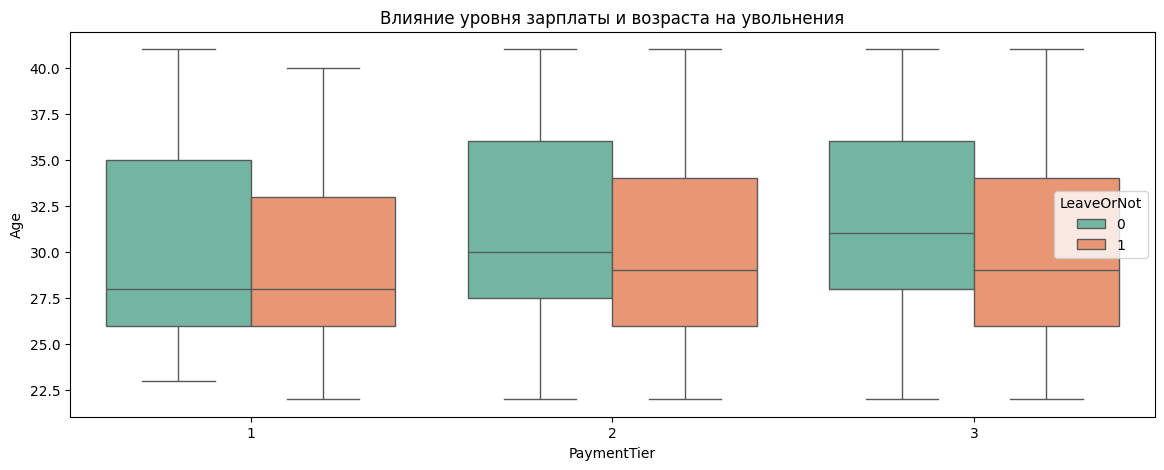

In [ ]:
plt.figure(figsize=(14,5))
sns.boxplot(data=df,x='PaymentTier',y='Age',hue='LeaveOrNot',palette='Set2')
plt.title("Влияние уровня зарплаты и возраста на увольнения")
plt.show()

Возраст уволившихся сотрудников в целом схож. Четкой зависимости между уровнем оплаты, возрастом и фактом увольнения не выявлено

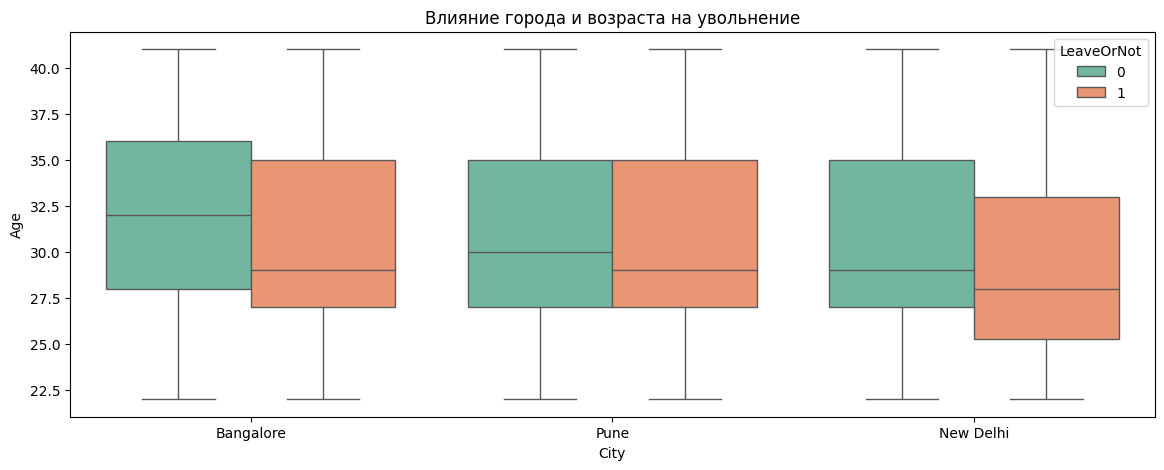

In [ ]:
plt.figure(figsize=(14,5))
sns.boxplot(data=df,x='City',y='Age',hue='LeaveOrNot',palette='Set2')
plt.title("Влияние города и возраста на увольнение")
plt.show()

Город проживания оказывает незначительное влияние на взаимосвязь возраста и увольнения.

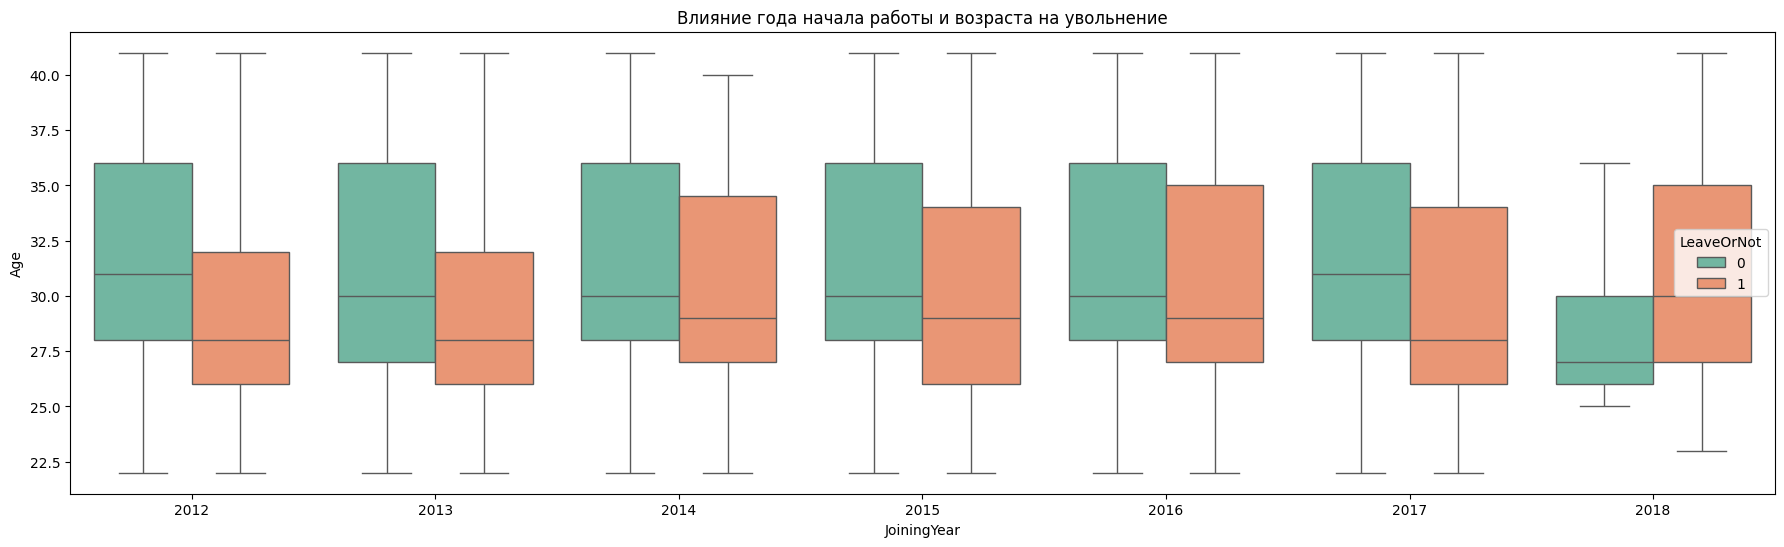

In [ ]:
plt.figure(figsize=(22,6))
sns.boxplot(data=df,x='JoiningYear',y='Age',hue='LeaveOrNot',palette='Set2')
plt.title("Влияние года начала работы и возраста на увольнение")
plt.show()

Возраст сотрудников в сочетании с годом начала работы оказывает ограниченное влияние на факт увольнения. В большинстве периодов увольнения чаще затрагивают более молодых сотрудников, однако эта зависимость нестабильна и меняется со временем. Для сотрудников, начавших работу в 2012–2017 годах, медианный возраст уволившихся сотрудников, как правило, ниже, чем у оставшихся. Это говорит о том, что среди более молодых сотрудников вероятность увольнения выше.В 2018 году наблюдается иная картина: медианный возраст уволившихся сотрудников выше, чем у оставшихся. Это может указывать на изменение структуры найма или условий работы в этот период.

Машинное обучение

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder=LabelEncoder()
df['Education']=encoder.fit_transform(df[['Education']])
df['City']=encoder.fit_transform(df[['City']])
df['Gender']=encoder.fit_transform(df[['Gender']])
df['EverBenched']=encoder.fit_transform(df[['EverBenched']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

In [ ]:
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,0,2017,0,3,34,1,0,0,0
1,0,2013,2,1,28,0,0,3,1
2,0,2014,1,3,38,0,0,2,0
3,1,2016,0,3,27,1,0,5,1
4,1,2017,2,3,24,1,1,2,1


Целевая переменная - LeaveOrNot. Нужно разделить на признаки (x)  и на целевую переменную (y)

In [ ]:
x = df.iloc[:, :-1]
x

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain
0,0,2017,0,3,34,1,0,0
1,0,2013,2,1,28,0,0,3
2,0,2014,1,3,38,0,0,2
3,1,2016,0,3,27,1,0,5
4,1,2017,2,3,24,1,1,2
...,...,...,...,...,...,...,...,...
2759,1,2017,2,2,31,0,0,2
2760,0,2016,2,3,30,1,0,2
2761,1,2013,2,2,37,1,0,2
2762,1,2018,1,3,27,1,0,5


In [ ]:
y = df.iloc[:, -1]
y

,LeaveOrNot
0,0
1,1
2,0
3,1
4,1
...,...
2759,0
2760,0
2761,1
2762,1


Разобьем на тестовую и обучающую выборку

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

**LogisticRegression**

In [ ]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = model_lr.predict(X_test)

In [ ]:
confusion_matrix(y_test, y_pred)

array([[284,  49],
       [142,  78]])

In [ ]:
accuracy_score(y_test, y_pred)*100

65.46112115732369

In [ ]:
model_lr.score(X_test,y_test)*100

65.46112115732369

In [ ]:

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      0.85      0.75       339
           1       0.58      0.33      0.42       214

    accuracy                           0.65       553
   macro avg       0.63      0.59      0.59       553
weighted avg       0.63      0.65      0.62       553



Модель логистической регрессии показала среднюю точность (0.67), но низкую полноту для класса ухода сотрудников (Recall = 0.38). В текущем виде модель пригодна лишь как базовое решение

**RandomForestClassifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200,random_state=42,class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
print(rf.score(X_train,y_train)*100)

93.53233830845771


In [ ]:
print(rf.score(X_test,y_test)*100)

72.33273056057867


Сильный разрыв между результатами на обучающей и тестовой выборках свидетельствует о наличии переобучения, что требует дополнительной настройки гиперпараметров модели

In [ ]:
rf_1=RandomForestClassifier(max_depth=5,n_estimators=100)
rf_1.fit(X_train,y_train)

RandomForestClassifier(max_depth=5)

In [ ]:
print(rf_1.score(X_train,y_train)*100)

79.55676164631389


In [ ]:
print(rf_1.score(X_test,y_test)*100)

78.84267631103074


In [ ]:
y_pred_rf = rf_1.predict(X_test)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.75      0.98      0.85       339
           1       0.94      0.49      0.64       214

    accuracy                           0.79       553
   macro avg       0.84      0.73      0.75       553
weighted avg       0.82      0.79      0.77       553



Модель хорошо распознаёт класс 0 (recall = 0.96), но для класса 1 точность высокая (precision = 0.90), а полнота низкая (recall = 0.52).  
Общая точность модели 77%, F1-score 0.76.

**XGBClassifier**

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, max_depth=3)
xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print(xgb.score(X_train,y_train)*100)

83.2654907281773


In [ ]:
print(xgb.score(X_test,y_test)*100)

81.55515370705244


In [ ]:
y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.79      0.94      0.86       339
           1       0.85      0.60      0.71       214

    accuracy                           0.81       553
   macro avg       0.82      0.77      0.78       553
weighted avg       0.81      0.81      0.80       553



**KNeighborsClassifier**

In [ ]:
knn=KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=11)

In [ ]:
print(knn.score(X_train,y_train)*100)

76.88828584350973


In [ ]:
print(knn.score(X_test,y_test)*100)

69.25858951175407


**SVC**

In [ ]:
svc=SVC(C=10,kernel='linear',gamma=0.8)
svc.fit(X_train,y_train)

SVC(C=10, gamma=0.8, kernel='linear')

In [ ]:
print(svc.score(X_train,y_train)*100)

66.3048394391678


In [ ]:
print(svc.score(X_test,y_test)*100)

67.63110307414105


**CatBoostClassifier**

In [ ]:
cat = CatBoostClassifier(
    iterations=500,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='Accuracy',
    early_stopping_rounds=50,
    verbose=0,
    random_seed=42
)

cat.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=0
)

CatBoostClassifier(early_stopping_rounds=50, eval_metric='Accuracy', iterations=500, learning_rate=0.1, max_depth=5, random_seed=42, verbose=0)

In [ ]:
y_pred_cat = cat.predict(X_test)

print(classification_report(y_test, y_pred_cat, target_names=['Остался', 'Ушёл']))

              precision    recall  f1-score   support

     Остался       0.79      0.95      0.87       333
        Ушёл       0.90      0.63      0.74       220

    accuracy                           0.82       553
   macro avg       0.85      0.79      0.80       553
weighted avg       0.83      0.82      0.82       553



In [ ]:
print(cat.score(X_train,y_train)*100)

83.12980551786522


In [ ]:
print(cat.score(X_test,y_test)*100)

82.27848101265823


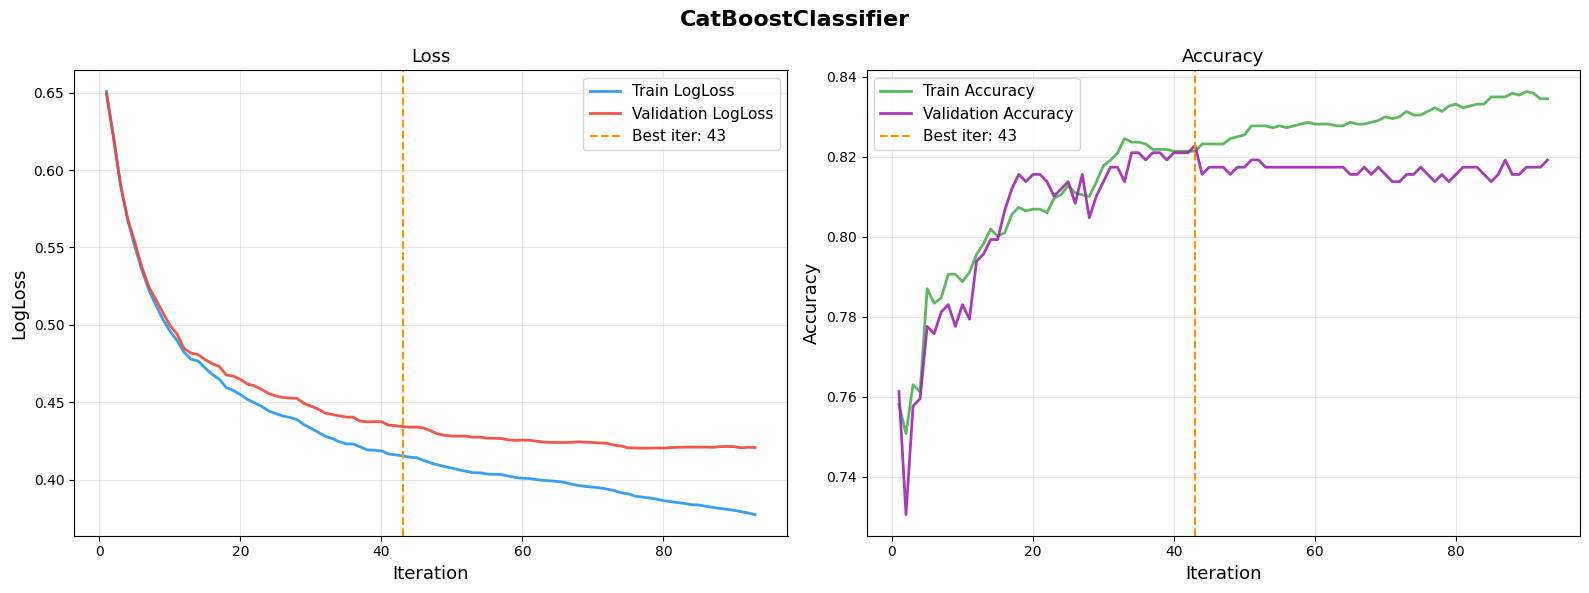

Лучшая итерация (early stopping): 43
Final Train LogLoss:       0.4155
Final Validation LogLoss:  0.4344


In [ ]:
evals_result = cat.get_evals_result()

train_loss = np.array(evals_result['learn']['Logloss'])
val_loss   = np.array(evals_result['validation']['Logloss'])
train_acc  = list(evals_result['learn']['Accuracy'])
val_acc    = list(evals_result['validation']['Accuracy'])
iterations = np.arange(1, len(train_loss) + 1)

best_it = cat.best_iteration_ + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CatBoostClassifier',
             fontsize=16, fontweight='bold')

#log loss
ax1 = axes[0]
ax1.plot(iterations, train_loss, color='#2196F3', linewidth=2, label='Train LogLoss', alpha=0.9)
ax1.plot(iterations, val_loss,   color='#F44336', linewidth=2, label='Validation LogLoss', alpha=0.9)
ax1.axvline(x=best_it, color='#FF9800', linestyle='--', linewidth=1.5, label=f'Best iter: {best_it}')
ax1.set_xlabel('Iteration', fontsize=13)
ax1.set_ylabel('LogLoss', fontsize=13)
ax1.set_title('Loss', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

#Accuracy
ax2 = axes[1]
ax2.plot(iterations, train_acc, color='#4CAF50', linewidth=2, label='Train Accuracy', alpha=0.9)
ax2.plot(iterations, val_acc,   color='#9C27B0', linewidth=2, label='Validation Accuracy', alpha=0.9)
ax2.axvline(x=best_it, color='#FF9800', linestyle='--', linewidth=1.5, label=f'Best iter: {best_it}')
ax2.set_xlabel('Iteration', fontsize=13)
ax2.set_ylabel('Accuracy', fontsize=13)
ax2.set_title('Accuracy', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('catboost_classifier_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Лучшая итерация (early stopping): {best_it}")
print(f"Final Train LogLoss:       {train_loss[best_it-1]:.4f}")
print(f"Final Validation LogLoss:  {val_loss[best_it-1]:.4f}")

Сохранение модели

In [ ]:
import joblib

In [ ]:
joblib.dump(cat, "catboost_model.pkl")

['catboost_model.pkl']